# Hicks-Ray CSTR: the infinite horizon vs a long finite horizon

The model is the canonical declared Hicks-Ray CSTR from
[`models/hicks.py`](models/hicks.py): see the module for its construction.
Two cases of the same model. Case 1 runs five sampling steps with the
infinite-horizon terminal segment (`drto.infinite_horizon`,
[Dinh et al. 2025](https://doi.org/10.1016/j.jprocont.2025.103565)) carrying
the tail, which deactivates the declared terminal cost since the tail owns
the cost-to-go. Case 2 runs fifty steps of plain finite horizon with the
terminal cost live.

## Case 1: five samples plus the infinite-horizon tail

In [1]:
import pyomo.environ as pyo
import pyomo_pounce  # registers pounce with the native factory
from pyomo.contrib.solver.common.factory import SolverFactory
import drto
from models.hicks import hicks
from drto import plot_states, plot_controls, plot_stage_cost

m1 = hicks(N=5)
pyo.TransformationFactory("dae.collocation").apply_to(m1, wrt=m1.t, nfe=5, ncp=3, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.infinite_horizon").apply_to(
    m1,
    nfe=3,                    # finite elements on the terminal segment
    ncp=5,                    # Gauss-Legendre points per element
    beta=1.2,                 # tail overestimation factor, > 1
    gamma="rule",             # the mesh rule, tanh(gamma*h) = tau_11; pass a number to override
    profile="collocation",    # segment control profile (pyomo-cvp)
)
pyo.TransformationFactory("drto.parameterize").apply_to(m1)  # the finite-horizon profiles
drto.build_objective(m1)
SolverFactory("pounce").solve(m1, tee=True)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.10.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpiuea09e5\unknownl2iehaxy.nl...
Parsed

   4  1.9531632e-01 4.72e-04 1.23e-02   -3.8 3.88e-02      - 9.27e-01 1.00e+00f  1
   5  1.9129395e-01 2.64e-04 7.55e-04   -3.8 2.45e-02      - 1.00e+00 1.00e+00h  1
   6  1.8649917e-01 3.32e-06 1.47e-05   -5.7 3.27e-03      - 1.00e+00 1.00e+00h  1
   7  1.8644335e-01 7.84e-10 2.66e-09   -8.6 6.69e-05      - 1.00e+00 1.00e+00h  1


Number of Iterations....: 7

                                   (scaled)                 (unscaled)
Objective...............:   1.8644335232146692e-02    1.8644335232146692e-01
Dual infeasibility......:   2.6623038729340914e-09    2.6623038729340914e-08
Constraint violation....:   7.8425961558270529e-10    7.8425961558270529e-10
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   3.5706126879089045e-09    3.5706126879089044e-08
Overall NLP error.......:   3.5706126879089045e-09    3.5706126879089044e-08


Number of objective function evaluations             = 8
Number of objective gradient evaluations     

In [2]:
drto.info(m1)

<drto registry>
states: 2, controls: 2
declarations:
  horizon: t (ContinuousSet, 16 points)
  states: zc (free), zt (free)
  dynamics: dzc[t]  ==  (1 - zc[t])/(u2sf*v2[t]) - k0*zc[t]*exp(- ea/zt[t])  for t in t
  dynamics: dzt[t]  ==  (ztf - zt[t])/(u2sf*v2[t]) + k0*zc[t]*exp(- ea/zt[t]) - a0*u1sf*v1[t]*(zt[t] - ztcw)  for t in t
  controls: v1 (piecewise_constant, free), v2 (piecewise_constant, free)
  tracking stage cost: cost[t]  ==  10*(zc[t] - zc_ss)**2 + 2*(zt[t] - zt_ss)**2 + (v1[t] - v1_ss)**2 + 0.5*(v2[t] - v2_ss)**2  for t in sorted(t)[:-1]
  terminal cost: term  ==  10*(zc[5] - zc_ss)**2 + 2*(zt[5] - zt_ss)**2
  initial conditions: zc[0]  ==  zc_hat
  initial conditions: zt[0]  ==  zt_hat
  steady-state targets: zc_ss (of zc), zt_ss (of zt)
  steady-state control targets: v1_ss (of v1), v2_ss (of v2)
transformations:
  drto.infinite_horizon: segment=3 elements x 5 Legendre points, beta=1.2, gamma=0.01563827, profile=collocation, horizon=kept, infinite tail appended, terminal_cost=terminal deactivated (the tail owns it), terminal=soft pin z(tau=1)=z_s on 2 states, mu=1000.0
  drto.parameterize: profiles=v1 (piecewise_constant), v2 (piecewise_constant)
  drto.build_objective: objective=sum of 28 weighted cost terms

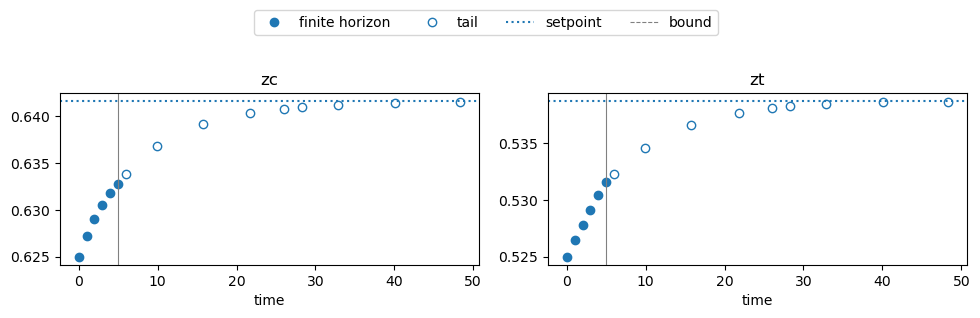

In [3]:
plot_states(m1);

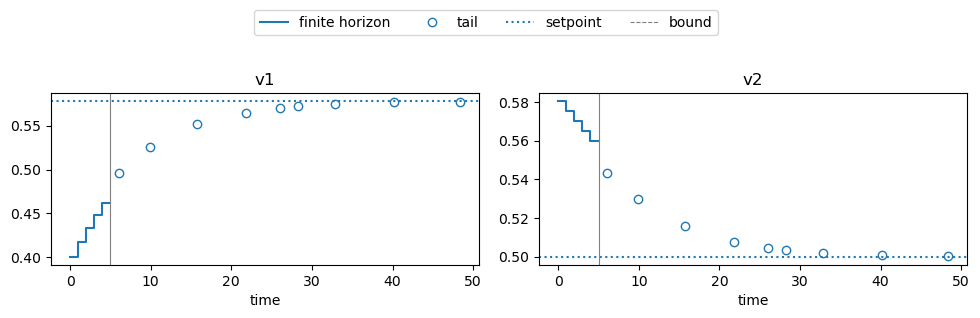

In [4]:
plot_controls(m1);

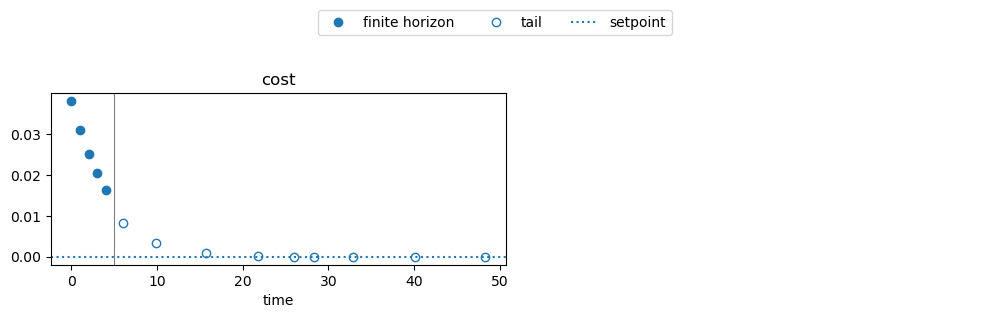

In [5]:
plot_stage_cost(m1);

## Case 2: fifty samples, finite horizon with the terminal cost

In [6]:
m2 = hicks(N=50)
pyo.TransformationFactory("dae.collocation").apply_to(m2, wrt=m2.t, nfe=50, ncp=3, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.parameterize").apply_to(m2)
drto.build_objective(m2)
SolverFactory("pounce").solve(m2, tee=True)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.10.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpzk2hjtj0\unknownob3z_z6j.nl...
Parsed

   5  1.7672213e-01 7.37e-08 2.08e-07   -5.7 1.19e-04      - 1.00e+00 1.00e+00h  1
   6  1.7672290e-01 1.19e-11 3.34e-11   -8.6 1.67e-06      - 1.00e+00 1.00e+00h  1


Number of Iterations....: 6

                                   (scaled)                 (unscaled)
Objective...............:   1.7672290497246815e-01    1.7672290497246815e-01
Dual infeasibility......:   3.3403781260141208e-11    3.3403781260141208e-11
Constraint violation....:   1.1897095377455660e-11    1.1897095377455660e-11
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   2.5115695718179517e-09    2.5115695718179517e-09
Overall NLP error.......:   2.5115695718179517e-09    2.5115695718179517e-09


Number of objective function evaluations             = 7
Number of objective gradient evaluations             = 7
Number of equality constraint evaluations            = 7
Number of inequality constraint evaluations          = 7
Number of equality constraint Jacobian e

In [7]:
drto.info(m2)

<drto registry>
states: 2, controls: 2
declarations:
  horizon: t (ContinuousSet, 151 points)
  states: zc (free), zt (free)
  dynamics: dzc[t]  ==  (1 - zc[t])/(u2sf*v2[t]) - k0*zc[t]*exp(- ea/zt[t])  for t in t
  dynamics: dzt[t]  ==  (ztf - zt[t])/(u2sf*v2[t]) + k0*zc[t]*exp(- ea/zt[t]) - a0*u1sf*v1[t]*(zt[t] - ztcw)  for t in t
  controls: v1 (piecewise_constant, free), v2 (piecewise_constant, free)
  tracking stage cost: cost[t]  ==  10*(zc[t] - zc_ss)**2 + 2*(zt[t] - zt_ss)**2 + (v1[t] - v1_ss)**2 + 0.5*(v2[t] - v2_ss)**2  for t in sorted(t)[:-1]
  terminal cost: term  ==  10*(zc[50] - zc_ss)**2 + 2*(zt[50] - zt_ss)**2
  initial conditions: zc[0]  ==  zc_hat
  initial conditions: zt[0]  ==  zt_hat
  steady-state targets: zc_ss (of zc), zt_ss (of zt)
  steady-state control targets: v1_ss (of v1), v2_ss (of v2)
transformations:
  drto.parameterize: profiles=v1 (piecewise_constant), v2 (piecewise_constant)
  drto.build_objective: objective=sum of 51 weighted cost terms

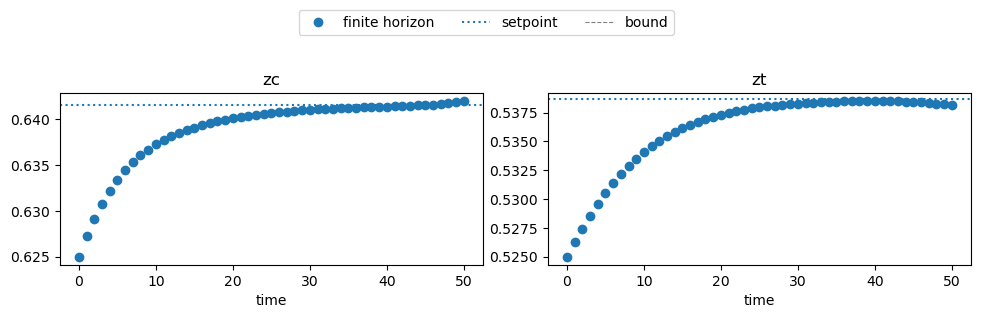

In [8]:
plot_states(m2);

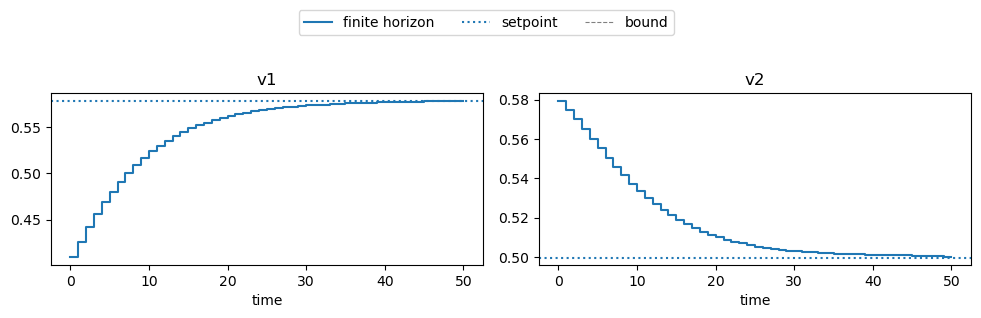

In [9]:
plot_controls(m2);

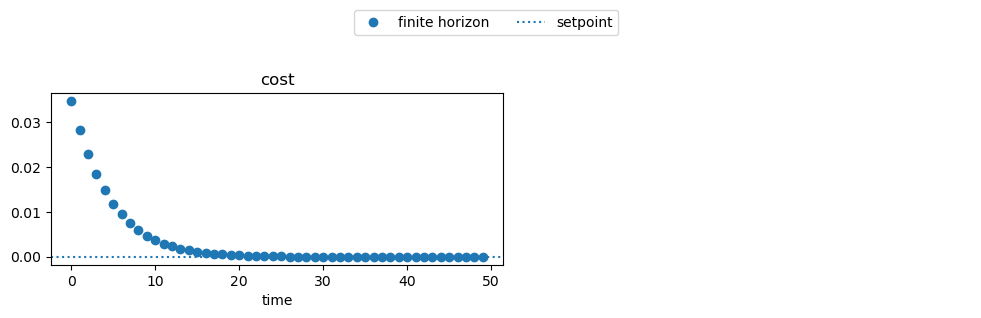

In [10]:
plot_stage_cost(m2);